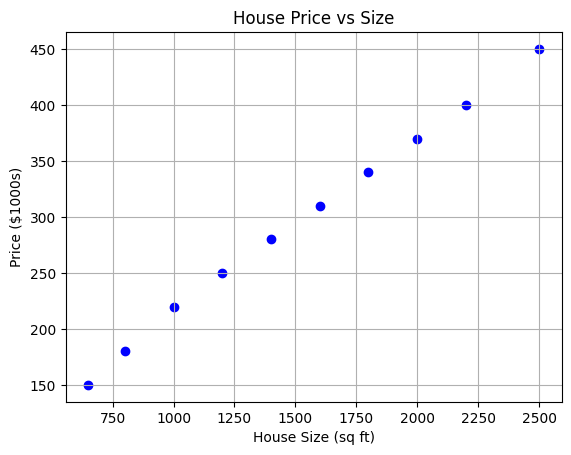

Number of examples: 10
Average size: 1515 sq ft
Average price: $295k


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Simple house price dataset
# Feature: Size in square feet
# Target: Price in thousands of dollars

size = np.array([650, 800, 1000, 1200, 1400, 1600, 1800, 2000, 2200, 2500])
price = np.array([150, 180, 220, 250, 280, 310, 340, 370, 400, 450])

# Visualize
plt.scatter(size, price, color='blue', marker='o')
plt.xlabel('House Size (sq ft)')
plt.ylabel('Price ($1000s)')
plt.title('House Price vs Size')
plt.grid(True)
plt.show()

print(f"Number of examples: {len(size)}")
print(f"Average size: {np.mean(size):.0f} sq ft")
print(f"Average price: ${np.mean(price):.0f}k")

In [4]:
def linear_model(x, w, b): 
    """
    Computes the linear model 
    Args:
      x (scalar): Input to the model (Size) 
      y (scalar): Label (Price)
    Returns
      f (scalar): The prediction of the model  
     """
    
    f = x * w + b
    return f 

In [5]:
def cost_function(x, y, w, b):
    """
    Computes the cost function
    Args:
      x (scalar): Input to the model (Size) 
      y (scalar): Label (Price)
      w, b (scalar): Parameters of the model  
    Returns
      cost (scalar): The cost (difference between real y and prediction)
     """
    cost = (linear_model(x,w,b) - y) ** 2
    return cost

In [6]:
def cost_total_function (x, y, w, b):
    """
    Computes the total cost function for all dataset
    Args:
      x (ndarray): Shape (m,) Input to the model (Size) 
      y (ndarray): Shape (m,) Label (Price)
      w, b (scalar): Parameters of the model  
    Returns
      cost_total (scalar): The total cost (difference between real y and prediction)
     """

    # Number of elements to cycle through
    m = len(x)
    total_cost = 0

    for i in range (m):
        total_cost = total_cost + cost_function(x[i], y[i], w, b)
    total_cost = total_cost/(2 * m)

    return total_cost
        


In [7]:
def compute_gradient(x, y, w, b): 
    """
    Computes the gradient for linear regression 
    Args:
      x (ndarray): Shape (m,) Input to the model (Population of cities) 
      y (ndarray): Shape (m,) Label (Actual profits for the cities)
      w, b (scalar): Parameters of the model  
    Returns
      dj_dw (scalar): The gradient of the cost w.r.t. the parameters w
      dj_db (scalar): The gradient of the cost w.r.t. the parameter b     
     """
    
    # Number of training examples
    m = len(x)
    
    dj_dw = 0
    dj_db = 0
    
    for i in range (m):
        dj_db = dj_db + ((w * x[i] + b) - y[i])
        dj_dw = dj_dw + (((w * x[i] + b) - y[i]) * x[i])
    
    dj_db = dj_db/m
    dj_dw = dj_dw/m 
    
    return dj_dw, dj_db

In [16]:
def gradient_descent(x, y, w, b, learning_rate, num_iters): 
    """
    Computes the gradient for linear regression 
    Args:
      x (ndarray): Shape (m,) Input to the model (Population of cities) 
      y (ndarray): Shape (m,) Label (Actual profits for the cities)
      w, b (scalar): Parameters of the model  
      learning_rate (scalar): learning rate used to update w and b
      num_iters (scalar): Limit to the number of iteration
    Returns
      w: the selected value for w
      b: the selected value for b
     """

    for i in range (num_iters):
        
        total_cost = cost_total_function (x, y, w, b)
        dj_dw, dj_db = compute_gradient(x, y, w, b)
        
        # Update w and b for next iteration
        w = w - learning_rate * dj_dw           
        b = b - learning_rate * dj_db

    return w,b

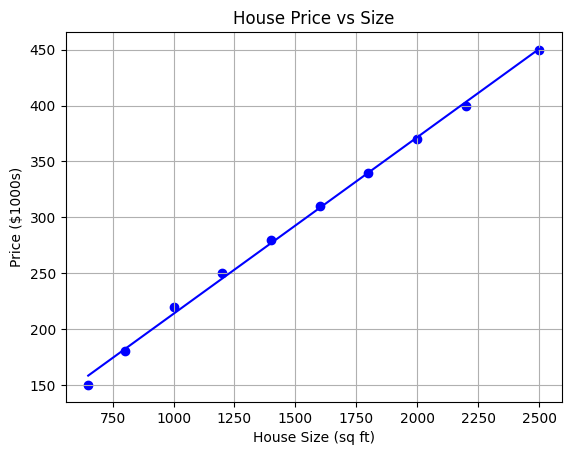

In [20]:
w = 0
b = 0

# Scale the features
scaler_x = StandardScaler()
scaler_y = StandardScaler()

size_scaled = scaler_x.fit_transform(size.reshape(-1, 1)).flatten()
price_scaled = scaler_y.fit_transform(price.reshape(-1, 1)).flatten()

w, b = gradient_descent (size_scaled, price_scaled, w, b, 0.1, 200)

m = size.shape[0]
predicted_scaled = np.zeros(m)

for i in range(m):
    predicted_scaled[i] = w * size_scaled[i] + b

# INVERSE TRANSFORM: Convert predictions back to original scale
predicted_original = scaler_y.inverse_transform(predicted_scaled.reshape(-1, 1)).flatten()

# Plot the linear fit
plt.plot(size, predicted_original, c = "b")

plt.scatter(size, price, color='blue', marker='o')
plt.xlabel('House Size (sq ft)')
plt.ylabel('Price ($1000s)')
plt.title('House Price vs Size')
plt.grid(True)
plt.show()